# Setup and Starter Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models, callbacks
from keras.datasets import cifar10
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test:{x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

c:\Users\roojy\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test:(10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


# 🟢 Task 1: Data Preprocessing Experiments

## 🔴 1A. Normalization Comparison

### ⚫ Description: Comparing No Normalization, Min-Max, and Standardization.

In [2]:
from tensorflow import keras
def BaselineCNN():
  model = models.Sequential([
      layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
      layers.MaxPooling2D((2, 2)),
      layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2)),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])
  return model

# EXP A
x_train_A = x_train.copy()
x_val_A = x_val.copy()
x_test_A = x_test.copy()

# EXP B
x_train_B = x_train / 255.0
x_val_B = x_val / 255.0
x_test_B = x_test / 255.0

# EXP C
mean = x_train.mean(axis=(0, 1, 2))
std = x_train.std(axis=(0, 1, 2))

x_train_C = (x_train - mean) / std
x_val_C = (x_val - mean) / std
x_test_C = (x_test - mean) / std

In [ ]:
# Training Config
EPOCHS = 20
BATCH_SIZE = 128

# Dictionary to store different preprocessing versions of the dataset
experiments = {
    'Raw': (x_train_A, x_val_A,  x_test_A),
    'Min-Max': (x_train_B, x_val_B,  x_test_B),
    'Standardized': (x_train_C, x_val_C,  x_test_C),
}

histories = {}
# Loop over each preprocessing method
for name, (x_tr, x_v, x_te) in experiments.items():
    model = BaselineCNN()
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_tr, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(x_v, y_val),
        verbose=1
    )

    # Save training history (used later for plotting curves)
    histories[name] = history
    loss, acc = model.evaluate(x_te, y_test, verbose=0)
    print(f"{name} → Test Acc: {acc*100:.2f}%  |  Loss: {loss:.4f}")

In [ ]:
# Plot 1: Training Loss
plt.figure(figsize=(10, 5))
for name, h in histories.items():
    plt.plot(h.history['loss'], label=name)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.xticks(range(0, EPOCHS, 2))
plt.show()

# Plot 2: Validation Accuracy
plt.figure(figsize=(10, 5))
for name, h in histories.items():
    plt.plot(h.history['val_accuracy'], label=name)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.xticks(range(0, EPOCHS, 2))
plt.show()

## 🔴 1B. Data Augmentation Comparison

### ⚫ Description: Using the standardized data from Exp C, train the BaselineCNN with and without data augmentation

In [ ]:
# Training Config
EPOCHS = 40
BATCH_SIZE = 128

# Exp 1 : No Augmentation
model_withoutAug = BaselineCNN()
model_withoutAug.compile(optimizer=keras.optimizers.Adam(0.001),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

history_withoutAug = model_withoutAug.fit(x_train_C, y_train,
                                         epochs=EPOCHS, batch_size=BATCH_SIZE,
                                         validation_data=(x_val_C, y_val), verbose=1)

loss_withoutAug, acc_withoutAug = model_withoutAug.evaluate(x_test_C, y_test, verbose=0)
print(f"No Augmentation → Test Acc: {acc_withoutAug*100:.2f}%  |  Loss: {loss_withoutAug:.4f}")

# Exp 2: With Augmentation
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train_C)

model_withAug = BaselineCNN()
model_withAug.compile(optimizer=keras.optimizers.Adam(0.001),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_withAug = model_withAug.fit(datagen.flow(x_train_C, y_train, batch_size=BATCH_SIZE),
                                    epochs=EPOCHS,
                                    validation_data=(x_val_C, y_val), verbose=1)

loss_withAug, acc_withAug = model_withAug.evaluate(x_test_C, y_test, verbose=0)
print(f"With Augmentation → Test Acc: {acc_withAug*100:.2f}%  |  Loss: {loss_withAug:.4f}")

In [ ]:
# Plot 1: Training Loss
plt.figure(figsize=(10, 5))
plt.plot(history_withoutAug.history['loss'], label='No Augmentation')
plt.plot(history_withAug.history['loss'], label='With Augmentation')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(0, EPOCHS, 2))
plt.legend()
plt.show()

# Plot 2: Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_withoutAug.history['val_accuracy'], label='No Augmentation')
plt.plot(history_withAug.history['val_accuracy'], label='With Augmentation')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(0, EPOCHS, 2))
plt.legend()
plt.show()

# 🟢 Task 2: CNN Architecture Experiments

## ⚫ Use standardized data for ALL experiments in this task.

## 🔴 2A. Filter Count Comparison

### ⚫ Description: Testing Small, Medium, and Large filter configurations.

In [3]:
import time
import pandas as pd

# Function to build models with diffrent filter counts
def build_model_2a(f1, f2, f3, f4):
    model = models.Sequential([
        layers.Conv2D(f1, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(f2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(f3, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

filter_configs = {
    'Small': (8, 8, 16, 16),
    'Medium': (32, 32, 64, 64),
    'Large': (64, 64, 128, 128)
}

histories_2a = {}
results_2a = []

for name, (f1, f2, f3, f4) in filter_configs.items():
    print(f"\n=================================")
    print(f"Training Model: {name} Filter Count")
    print(f"=================================")

    model = build_model_2a(f1, f2, f3, f4)
    model.summary()

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # train model
    start_time = time.time()
    history = model.fit(
        x_train_C, y_train,
        epochs=20,
        batch_size=128,
        validation_data=(x_val_C, y_val),
        verbose=1
    )
    time_taken = time.time() - start_time

    histories_2a[name] = history

    # Evaluation
    test_loss, test_acc = model.evaluate(x_test_C, y_test, verbose=0)

    # Store metrics for table
    results_2a.append({
        'Model': name,
        'Total Params': model.count_params(),
        'Train Acc': history.history['accuracy'][-1],
        'Val Acc': history.history['val_accuracy'][-1],
        'Test Acc': test_acc,
        'Time (s)': time_taken
    })

# results Table
df_2a = pd.DataFrame(results_2a)
print(f"\n=================================")
print("Results: Filter Count Comparison")
print(f"=================================")
display(df_2a)


Training Model: Small Filter Count


c:\Users\roojy\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

In [ ]:
# Plot val accuracy curves for all 3 on one graph
plt.figure(figsize=(10, 6))
for name, h in histories_2a.items():
    plt.plot(h.history['val_accuracy'], label=f'{name} Model', lw=2)

plt.title('Validation Accuracy - Filter Count Comparison', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.xticks(range(0, 20, 2))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 🔴 2B. Network Depth Comparison

### ⚫ Description: Comparing Shallow (4 layers), Medium (6 layers), and Deep (8 layers).

In [ ]:
def build_shallow():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_medium_depth():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_deep():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

depth_models = {
    'Shallow': build_shallow(),
    'Medium': build_medium_depth(),
    'Deep': build_deep()
}

histories_2b = {}
results_2b = []

for name, model in depth_models.items():
    print(f"\n=================================")
    print(f"Training Model: {name} Depth")
    print(f"=================================")

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    start_time = time.time()
    history = model.fit(
        x_train_C, y_train,
        epochs=20,
        batch_size=128,
        validation_data=(x_val_C, y_val),
        verbose=1
    )
    time_taken = time.time() - start_time

    histories_2b[name] = history
    test_loss, test_acc = model.evaluate(x_test_C, y_test, verbose=0)

    results_2b.append({
        'Model': name,
        'Total Params': model.count_params(),
        'Train Acc': history.history['accuracy'][-1],
        'Val Acc': history.history['val_accuracy'][-1],
        'Test Acc': test_acc,
        'Time (s)': time_taken
    })

# Results Table
df_2b = pd.DataFrame(results_2b)
print(f"\n=================================")
print("Results Table 2B: Network Depth Comparison")
print(f"=================================")
display(df_2b)

In [ ]:
# Plot training loss and val loss (2 curves per plot, 3 separate plots)
for name, h in histories_2b.items():
    plt.figure(figsize=(8, 5))
    plt.plot(h.history['loss'], label='Training Loss', lw=2)
    plt.plot(h.history['val_loss'], label='Validation Loss', lw=2)

    plt.title(f'{name} Depth Model: Training & Validation Loss', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.xticks(range(0, 20, 2))
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# 🟢 Task 3: Regularization Experiments

## ⚫ Use the Medium model from Task 2A as the baseline for all experiments.

## 🔴 3A. Dropout Rate Comparison

### ⚫ Description: Comparing rates of 0.0, 0.25, and 0.5.

In [4]:
def build_D0():
    return build_model_2a(32, 32, 64, 64)  # Medium filter config from 2A

def build_D1():
    # 2A Medium + Dropout(0.25)
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),                   
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),                   
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.25),                   
        layers.Dense(10, activation='softmax')
    ], name='D1_dropout_025')
    return model

def build_D2():
    # 2A Medium + Dropout(0.5)
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.5),                   
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.5),                    
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),                    
        layers.Dense(10, activation='softmax')
    ], name='D2_dropout_050')
    return model

In [ ]:
# Training 

model_builders = {'D0': build_D0, 'D1': build_D1, 'D2': build_D2}
histories = {}

for name, builder in model_builders.items():
    print(f"Training {name}")
    model = builder()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        x_train_C, y_train,
        epochs=30,
        batch_size=128,
        validation_data=(x_val_C, y_val),
        verbose=1
    )
    histories[name] = history
    test_loss, test_acc = model.evaluate(x_test_C, y_test, verbose=0)
    print(f"{name} → Test accuracy: {test_acc:.4f}")

In [ ]:
# Plot 1: Validation Accuracy
plt.figure(figsize=(10, 5))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Training Accuracy
plt.figure(figsize=(10, 5))
for name, history in histories.items():
    plt.plot(history.history['accuracy'], label=name)
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔴 3B. Early Stopping Comparison

### ⚫ Description: Comparing no ES vs. patience=5 vs. patience=10.

In [5]:
es_experiments = {
    'ES0': None,  # No early stopping, 50 epochs
    'ES2': callbacks.EarlyStopping(monitor='val_loss', patience=5,  restore_best_weights=True),
    'ES3': callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
}

es_histories = {}
es_results   = {}

In [ ]:
# Training
for name, callback in es_experiments.items():
    print(f"Training {name}")

    model = build_D0()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # If early stopping exists pass it as callback, otherwise empty list
    cb_list = [callback] if callback is not None else []

    start = time.time()
    history = model.fit(
        x_train_B, y_train,
        epochs=50,
        batch_size=128,
        validation_data=(x_val_B, y_val),
        callbacks=cb_list,
        verbose=1
    )
    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(x_test_B, y_test, verbose=0)
    stopped_at    = len(history.history['val_loss'])
    best_val_loss = min(history.history['val_loss'])

    es_histories[name] = history
    es_results[name]   = {
        'Stopped at Epoch': stopped_at,
        'Best Val Loss':    round(best_val_loss, 4),
        'Test Acc':         round(test_acc, 4),
        'Time (s)':         round(elapsed, 1)
    }

    print(f"{name} → Stopped at epoch {stopped_at} | "
          f"Best val loss: {best_val_loss:.4f} | "
          f"Test acc: {test_acc:.4f} | Time: {elapsed:.1f}s")

In [ ]:
# Plot: val loss with early stopping markers
plt.figure(figsize=(10, 5))

for name, history in es_histories.items():
    val_loss = history.history['val_loss']
    epochs   = range(1, len(val_loss) + 1)
    plt.plot(epochs, val_loss, label=name)

    # Mark stopping point with a vertical line only for ES2 and ES3
    if name != 'ES0':
        stopped_at = len(val_loss)
        plt.axvline(
            x=stopped_at,
            linestyle='--',
            label=f'{name} stopped at epoch {stopped_at}'
        )

plt.title('Validation Loss with Early Stopping Points')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 🟢 Task 4: Optimizer Comparison

## ⚫ Use the Medium model from Task 2A. Use standardized data.

## 🔴 4A. Same Learning Rate — 5 Optimizers.

### ⚫ Description: SGD, Momentum, AdaGrad, RMSProp, and Adam.

### ⚫ Train with all 5 optimizers at learning_rate = 0.001, 30 epochs, batch_size=128

In [ ]:
pass

## 🔴 4B. Learning Rate Sensitivity — Adam

### ⚫ Description: Testing LR values: 0.0001, 0.001, 0.01. (30 epochs, batch_size=128)

In [ ]:
pass

# 🟢 Task 5: Performance Evaluation

## 🔴 5A. Best Model Selection

In [ ]:
pass

## 🔴 5B. Error Analysis

In [ ]:
pass

# 🟢 Task 6: Transfer Learning

## 🔴 6A. Feature Extraction vs Fine-Tuning vs From Scratch

### ⚫ Step 1 — Resize CIFAR-10 for VGG16:

In [3]:
x_train_resized = tf.image.resize(x_train_C, (48, 48)).numpy()
x_val_resized = tf.image.resize(x_val_C, (48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_C, (48, 48)).numpy()

### ⚫ Model 1: From Scratch

- Build the Medium CNN from Task 2A with input_shape=(48, 48, 3). Train 20 epochs, Adam(lr=0.001),  batch_size=128.

In [4]:
# Medium CNN Model with 48x48 input
model_1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(48, 48, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
start_time = time.time()
model_1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),metrics=['accuracy'], loss='sparse_categorical_crossentropy')
history_1 = model_1.fit(x_train_resized, y_train, epochs=20, batch_size=128, validation_data=(x_val_resized, y_val), verbose=1)
time_taken_1 = time.time() - start_time
test_loss_1, test_acc_1 = model_1.evaluate(x_test_resized, y_test, verbose=0)
print(f"48x48 Input ---> Test Acc: {test_acc_1*100:.2f}%  |  Loss: {test_loss_1:.4f} | Time: {time_taken_1:.2f}s")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.4856 - loss: 1.4414 - val_accuracy: 0.5993 - val_loss: 1.1428
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6564 - loss: 0.9797 - val_accuracy: 0.6708 - val_loss: 0.9495
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7324 - loss: 0.7691 - val_accuracy: 0.6873 - val_loss: 0.9226
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7894 - loss: 0.6105 - val_accuracy: 0.6764 - val_loss: 0.9963
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8321 - loss: 0.4798 - val_accuracy: 0.6656 - val_loss: 1.1729
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8649 - loss: 0.3867 - val_accuracy: 0.6717 - val_loss: 1.2218
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8978 - loss: 0.2917 - val_accuracy: 0.6753 - val_loss: 1.4510
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9318 - loss: 0.1984 - val_ac

### ⚫ Model 2 — Feature Extraction (Frozen VGG16)

- Load a pre-trained VGG16 model (trained on ImageNet) without the top classification layers.

- Freeze ALL VGG16 layers so their weights do not update during training.

- Add your own classification head on top.

In [5]:
# loading VGG16 with imagenet weights, excluding top layers
from keras.applications import VGG16
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(48, 48, 3))
vgg_base.trainable = False
model_2 = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_2 = model_2.fit(x_train_resized, y_train, epochs=20, batch_size=128, validation_data=(x_val_resized, y_val), verbose=1)
time_taken_2 = time.time() - start_time

test_loss_2, test_acc_2 = model_2.evaluate(x_test_resized, y_test, verbose=0)
print(f"VGG16 Transfer Learning ---> Test Acc: {test_acc_2*100:.2f}%  |  Loss: {test_loss_2:.4f} | Time: {time_taken_2:.2f}s")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.5325 - loss: 1.3424 - val_accuracy: 0.6465 - val_loss: 1.0309
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.6333 - loss: 1.0564 - val_accuracy: 0.6678 - val_loss: 0.9605
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.6586 - loss: 0.9821 - val_accuracy: 0.6799 - val_loss: 0.9307
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.6727 - loss: 0.9398 - val_accuracy: 0.6845 - val_loss: 0.9115
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.6852 - loss: 0.9040 - val_accuracy: 0.6900 - val_loss: 0.9032
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.6951 - loss: 0.8753 - val_accuracy: 0.6930 - val_loss: 0.8943
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.7069 - loss: 0.8478 - val_accuracy: 0.6960 - val_loss: 0.8877
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━

### ⚫ Model 3 — Fine-Tuning (Partial Unfreeze)

- Load a pre-trained VGG16 model (same as Model 2).

- Freeze all layers EXCEPT the last 4 layers — these will be re-trained on CIFAR-10.

- Add the same classification head (Flatten → Dense(256) → Dropout → Dense(10)).

- Use a LOWER learning rate (1e-5) to avoid destroying the pre-trained weights.

In [6]:
vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:
    layer.trainable = False
model_3 = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model_3.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
start_time = time.time()
history_3 = model_3.fit(x_train_resized, y_train, epochs=20, batch_size=128, validation_data=(x_val_resized, y_val), verbose=1)
time_taken_3 = time.time() - start_time
test_loss_3, test_acc_3 = model_3.evaluate(x_test_resized, y_test, verbose=0)
print(f"VGG16 Fine-tuning ---> Test Acc: {test_acc_3*100:.2f}%  |  Loss: {test_loss_3:.4f} | Time: {time_taken_3:.2f}s")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.4199 - loss: 1.6567 - val_accuracy: 0.6692 - val_loss: 0.9775
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.6564 - loss: 1.0102 - val_accuracy: 0.7321 - val_loss: 0.7810
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.7143 - loss: 0.8407 - val_accuracy: 0.7553 - val_loss: 0.7037
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.7488 - loss: 0.7424 - val_accuracy: 0.7736 - val_loss: 0.6561
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.7735 - loss: 0.6738 - val_accuracy: 0.7849 - val_loss: 0.6221
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.7922 - loss: 0.6122 - val_accuracy: 0.7901 - val_loss: 0.5996
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.8110 - loss: 0.5654 - val_accuracy: 0.7996 - val_loss: 0.5823
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.8228 - loss: 0.5268 - 

### ⚫ Model 4 — Fine-Tuning (Higher Learning Rate)

- Same architecture and frozen layers as Model 3 (unfreeze last 4 VGG16 layers), but use a higher learning  rate (lr=0.001) instead of 1e-5.

In [7]:
model_4 = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model_4.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
start_time = time.time()
history_4 = model_4.fit(x_train_resized, y_train, epochs=20, batch_size=128, validation_data=(x_val_resized, y_val), verbose=1)
time_taken_4 = time.time() - start_time
test_loss_4, test_acc_4 = model_4.evaluate(x_test_resized, y_test, verbose=0)
print(f"VGG16 Fine-tuning (LR=0.001) ---> Test Acc: {test_acc_4*100:.2f}%  |  Loss: {test_loss_4:.4f} | Time: {time_taken_4:.2f}s")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 80ms/step - accuracy: 0.0971 - loss: 2.3204 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.0986 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.0993 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.0978 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.0983 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.0987 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.0984 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.0990 - loss: 2.3027 - 

### ⚫Plotting

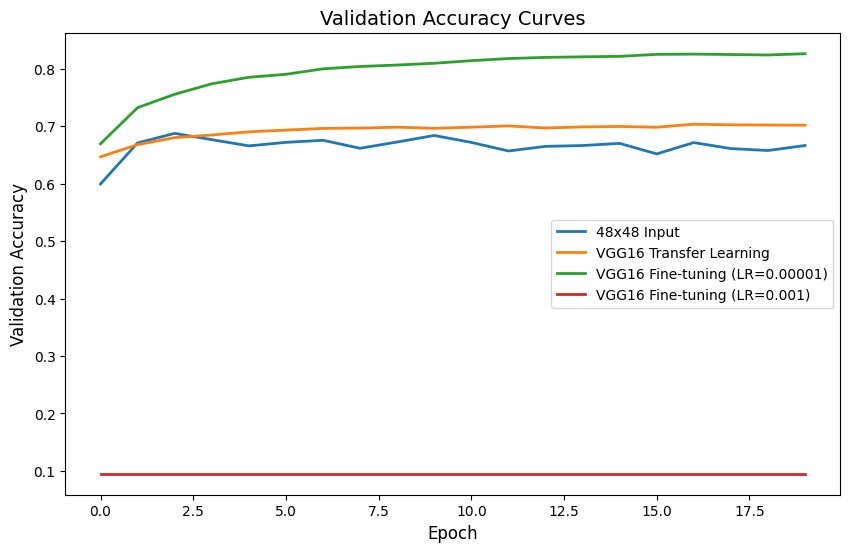

In [8]:
#plotting val accuracy curves for all 4 models on one graph
plt.figure(figsize=(10, 6))
plt.plot(history_1.history['val_accuracy'], label='48x48 Input', lw=2)
plt.plot(history_2.history['val_accuracy'], label='VGG16 Transfer Learning', lw=2)
plt.plot(history_3.history['val_accuracy'], label='VGG16 Fine-tuning (LR=0.00001)', lw=2)
plt.plot(history_4.history['val_accuracy'], label='VGG16 Fine-tuning (LR=0.001)', lw=2)
plt.title('Validation Accuracy Curves', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.legend()
plt.show()

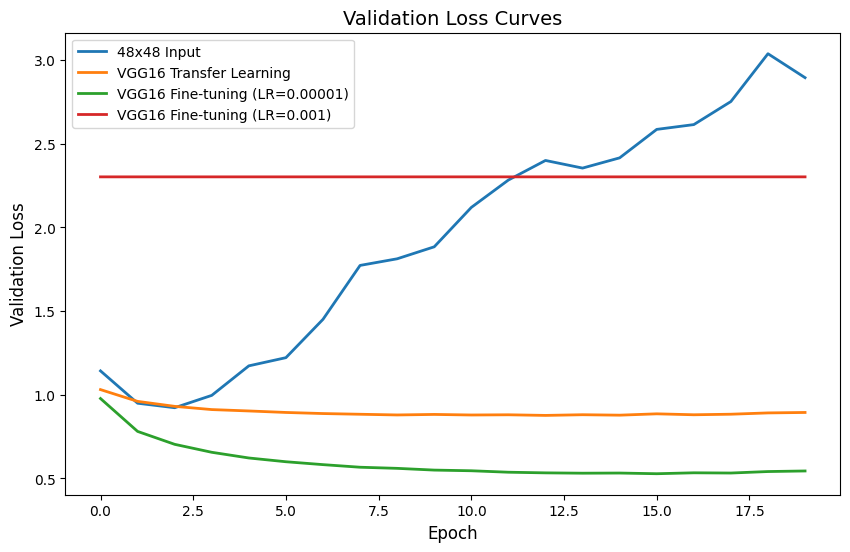

In [9]:
# plotting val loss curves for all 4 models on one graph
plt.figure(figsize=(10, 6))
plt.plot(history_1.history['val_loss'], label='48x48 Input', lw=2)
plt.plot(history_2.history['val_loss'], label='VGG16 Transfer Learning', lw=2)
plt.plot(history_3.history['val_loss'], label='VGG16 Fine-tuning (LR=0.00001)', lw=2)
plt.plot(history_4.history['val_loss'], label='VGG16 Fine-tuning (LR=0.001)', lw=2)
plt.title('Validation Loss Curves', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.legend()
plt.show()